In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
store_detail = pd.read_csv('StoreDetail.csv')
store_detail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


In [3]:
store_sales = pd.read_csv('StoreSales.csv')
store_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


In [4]:
products = pd.read_csv('Products.csv')
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


In [5]:
product_categories = pd.read_csv('ProductCategories.csv')
product_categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


In [6]:
customer_list = pd.read_csv('customer_list.csv', sep='|')
customer_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


In [7]:
nj_info = store_detail[store_detail['State'] == 'New Jersey']
nj_info[['Store ID', 'Store Location', 'Territory Manager', 'Region']]

,Store ID,Store Location,Territory Manager,Region
70,824,Atlantic City,Miami Vue,Northeast
71,825,Bayonne,Miami Vue,Northeast
72,826,Cape May,Miami Vue,Northeast
73,827,Clifton,Miami Vue,Northeast
74,828,East Orange,Miami Vue,Northeast
75,829,Hackensack,Miami Vue,Northeast
76,830,Hoboken,Miami Vue,Northeast
77,831,Jersey City,Miami Vue,Northeast
78,832,Montclair,Miami Vue,Northeast
79,833,Morristown,Miami Vue,Northeast


In [8]:
ma_info = store_detail[store_detail['State'] == 'Massachusetts']
ma_info[['Store ID', 'Store Location', 'Territory Manager', 'Region']]

,Store ID,Store Location,Territory Manager,Region
52,730,Boston,Bo Heap,Northeast
53,801,Attleboro,Bo Heap,Northeast
54,802,Falmouth,Bo Heap,Northeast
55,803,Framingham,Bo Heap,Northeast
56,804,Haverhill,Bo Heap,Northeast
57,805,Hingham,Bo Heap,Northeast
58,806,Holyoke,Bo Heap,Northeast
59,807,Leominster,Bo Heap,Northeast
60,808,Lowell,Bo Heap,Northeast
61,809,Lynn,Bo Heap,Northeast


In [9]:
# Change transaction dates to determine and create a Month column
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])
store_sales['Month'] = store_sales['Transaction Date'].dt.to_period('M')

# Get store IDs for each of the territories
ma_ids = store_detail[store_detail['State'] == 'Massachusetts']['Store ID'].tolist()
nj_ids = store_detail[store_detail['State'] == 'New Jersey']['Store ID'].tolist()

# Filter sales for each of the territories
ma_sales = store_sales[store_sales['Store ID'].isin(ma_ids)]
nj_sales = store_sales[store_sales['Store ID'].isin(nj_ids)]

print("Massachusetts sales rows:", len(ma_sales))
print("New Jersey sales rows:", len(nj_sales))

Massachusetts sales rows: 42010
New Jersey sales rows: 38195


In [10]:
# Massachusetts monthly revenue
ma_monthly = ma_sales.groupby('Month')['Sale Amount'].sum()
print("=== Massachusetts Monthly Revenue ===")
print(ma_monthly)

=== Massachusetts Monthly Revenue ===
Month
2022-01     69396.42
2022-02     65616.00
2022-03     77390.00
2022-04     81333.60
2022-05     75919.64
2022-06     81227.82
2022-07     67271.23
2022-08     73543.48
2022-09     58716.74
2022-10     72514.81
2022-11     70654.73
2022-12     70025.64
2023-01    139388.56
2023-02    104454.67
2023-03    112443.92
2023-04    109369.00
2023-05    109021.42
2023-06    101710.16
2023-07    120793.96
2023-08    126212.14
2023-09    121968.93
2023-10    113824.37
2023-11    105670.08
2023-12    101641.22
2024-01    117915.05
2024-02    103968.70
2024-03    110968.54
2024-04    107421.88
2024-05    106193.39
2024-06    116310.73
2024-07    126212.14
2024-08    123926.20
2024-09    111867.10
2024-10    110582.18
2024-11     96729.12
2024-12    139388.56
2025-01    150745.88
2025-02    140234.24
2025-03    160846.61
2025-04    156773.91
2025-05    157710.74
2025-06    170305.34
2025-07    191697.95
2025-08    174867.46
2025-09    168503.25
2025-10    

In [11]:
# New Jersey monthly revenue
nj_monthly = nj_sales.groupby('Month')['Sale Amount'].sum()
print("=== New Jersey Monthly Revenue ===")
print(nj_monthly)

=== New Jersey Monthly Revenue ===
Month
2022-01     70597.51
2022-02     63225.69
2022-03     64779.71
2022-04     78465.40
2022-05     73037.02
2022-06     66868.55
2022-07     72096.47
2022-08     73904.91
2022-09     77869.16
2022-10     83610.78
2022-11     70526.89
2022-12     84464.75
2023-01    115439.64
2023-02     91815.52
2023-03    101529.42
2023-04     94095.22
2023-05     93011.83
2023-06     88203.90
2023-07     98822.98
2023-08    107203.90
2023-09     95680.79
2023-10    108715.83
2023-11    106648.71
2023-12    111495.71
2024-01     99272.17
2024-02     96699.78
2024-03     95231.21
2024-04     91875.84
2024-05     89476.87
2024-06     97550.01
2024-07    107203.90
2024-08     98470.41
2024-09    105926.21
2024-10    110232.92
2024-11    107911.50
2024-12    115439.64
2025-01    148558.26
2025-02    131102.08
2025-03    138083.24
2025-04    138626.24
2025-05    133865.16
2025-06    144521.48
2025-07    149097.10
2025-08    151923.99
2025-09    163449.78
2025-10    250

In [12]:
# Massachusetts store rankings (From the highest revenue)
ma_store_rank = ma_sales.groupby('Store ID')['Sale Amount'].sum().sort_values(ascending=False)
print("=== Massachusetts Store Rankings ===")
print(ma_store_rank)

=== Massachusetts Store Rankings ===
Store ID
817    602183.44
807    338009.10
810    335547.81
814    328860.51
812    322039.24
806    320516.53
816    312873.59
804    305762.60
809    302049.65
813    301281.50
811    295443.42
730    295201.29
801    290883.71
805    289633.52
815    279646.07
802    276965.55
803    269375.91
808    266982.83
Name: Sale Amount, dtype: float64


In [13]:
# New Jersey store rankings (From the highest revenue)
nj_store_rank = nj_sales.groupby('Store ID')['Sale Amount'].sum().sort_values(ascending=False)
print("=== New Jersey Store Rankings ===")
print(nj_store_rank)

=== New Jersey Store Rankings ===
Store ID
835    623163.53
838    597565.68
830    316775.48
824    314513.77
834    311056.42
833    307320.52
839    306326.30
827    301703.77
836    300358.95
828    299936.24
831    296244.33
829    293676.93
825    292353.59
826    285704.59
832    261593.20
837     67112.57
Name: Sale Amount, dtype: float64


In [14]:
# Massachusetts top 10 customers (total spend)
ma_top_cust = ma_sales.groupby('RewardsID')['Sale Amount'].sum().sort_values(ascending=False).head(10).reset_index()
ma_top_cust['RewardsID'] = ma_top_cust['RewardsID'].astype('Int64')

# Match RewardsID to customer names
ma_top_cust = ma_top_cust.merge(customer_list, left_on='RewardsID', right_on='cust_id', how='left')
ma_top_cust[['RewardsID', 'name', 'Sale Amount']]

,RewardsID,name,Sale Amount
0,292,Beverly Crusher,4758.92
1,384,Tracy Jordan,4197.55
2,47,Stanley H.,3979.73
3,3,Monica Geller,3966.91
4,188,Mellie Grant,3948.41
5,300,Julian Bashir,3883.60
6,17,Mike E.,3788.67
7,316,Kaylee Frye,3725.87
8,344,Nate Jacobs,3569.36
9,178,Pamela James,3523.01


In [15]:
# Merge sales with products and categories for New Jersey
nj_merged = nj_sales.merge(products, on='Prod Num', how='left').merge(
            product_categories, on=['CategoryID', 'SubcategoryID'], how='left')

# Transactions per category
nj_cat_txn = nj_merged.groupby('Category').size().sort_values(ascending=False).reset_index()
nj_cat_txn.columns = ['Category', 'Transaction Count']

# Revenue per category
nj_cat_rev = nj_merged.groupby('Category')['Sale Amount'].sum().sort_values(ascending=False).reset_index()
nj_cat_rev.columns = ['Category', 'Total Revenue']
nj_cat_rev['Total Revenue'] = nj_cat_rev['Total Revenue'].round(2)

nj_cat_summary = nj_cat_txn.merge(nj_cat_rev, on='Category')
print('=== New Jersey: Revenue & Transactions by Category ===')
print(nj_cat_summary.to_string(index=False))

=== New Jersey: Revenue & Transactions by Category ===
                Category  Transaction Count  Total Revenue
 Stationery and Supplies               8265       83170.46
Technology & Accessories               7883     3630738.42
 Apparel and Merchandise               7353      237281.41
            Art Supplies               7162      225414.36
               Textbooks               5419      936799.67
         Books (General)               3146       90319.41


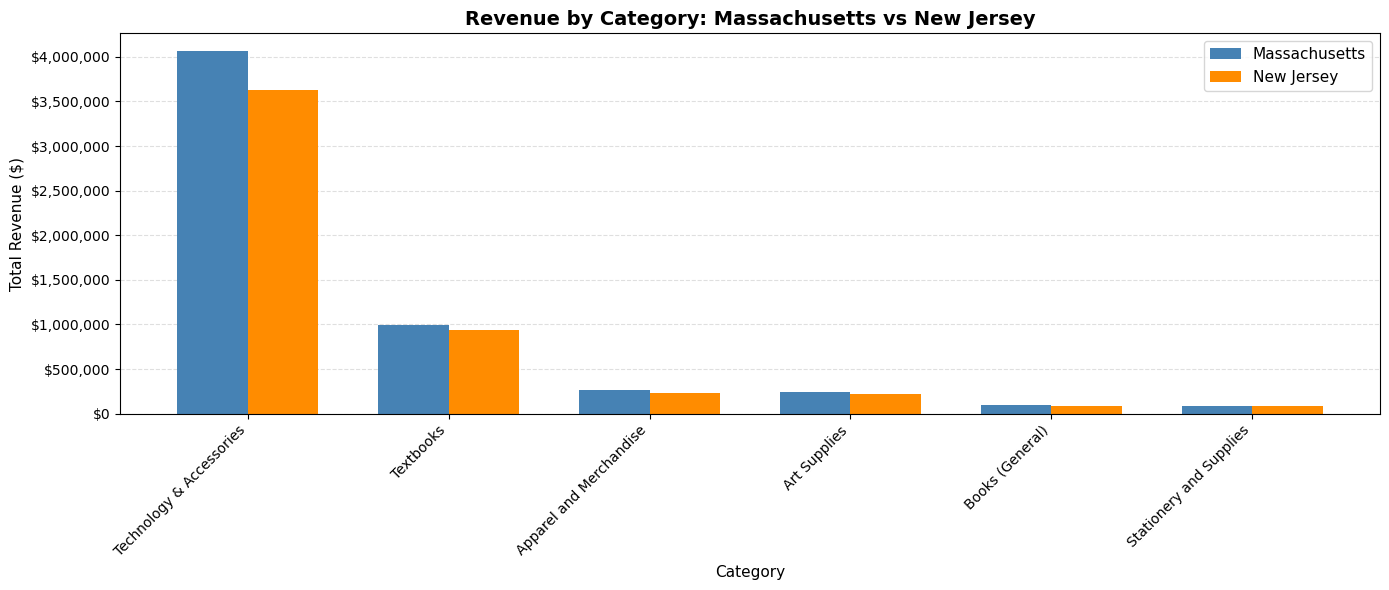

In [25]:
# Chart 1 Monthly Revenue Comparis (MA vs. NJ)
# Merge products, categories, sales, and store details into one DataFrame
mer_p_ss = products.merge(store_sales, on='Prod Num')
mer_pc_p_ss = product_categories.merge(mer_p_ss, on=['CategoryID', 'SubcategoryID'])
full_df = store_detail.merge(mer_pc_p_ss, on='Store ID')

# Convert transaction date and extract month
full_df['Transaction Date'] = pd.to_datetime(full_df['Transaction Date'])
mon = full_df['Transaction Date'].dt.to_period('M')

# Isolate each territory
ma_data = full_df.loc[full_df['State'] == 'Massachusetts']
nj_data = full_df.loc[full_df['State'] == 'New Jersey']

# Revenue by category for each territory
ma_cat_rev = ma_data.groupby('Category')['Sale Amount'].sum().sort_values(ascending=False)
nj_cat_rev = nj_data.groupby('Category')['Sale Amount'].sum().reindex(ma_cat_rev.index)

# Plot grouped bar chart
x = np.arange(len(ma_cat_rev))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, ma_cat_rev.values, width=width, color='steelblue', label='Massachusetts')
ax.bar(x + width/2, nj_cat_rev.values, width=width, color='darkorange', label='New Jersey')

ax.set_title('Revenue by Category: Massachusetts vs New Jersey', fontsize=14, fontweight='bold')
ax.set_xlabel('Category', fontsize=11)
ax.set_ylabel('Total Revenue ($)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(ma_cat_rev.index, rotation=45, ha='right', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'${val:,.0f}'))
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart1_revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


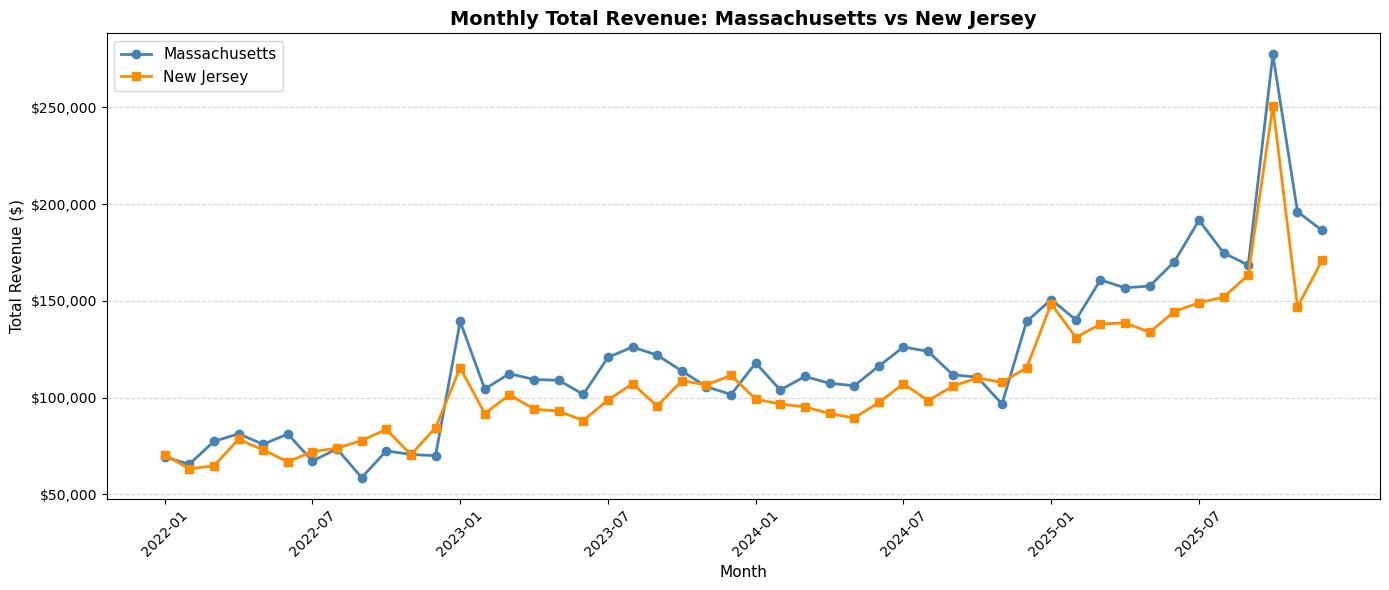

Chart 1 saved.


In [23]:
# Chart 2: Monthly Revenue Trend
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(ma_monthly.index.astype(str), ma_monthly.values,
        marker='o', color='steelblue', linewidth=2, label='Massachusetts')
ax.plot(nj_monthly.index.astype(str), nj_monthly.values,
        marker='s', color='darkorange', linewidth=2, label='New Jersey')

ax.set_title('Monthly Total Revenue: Massachusetts vs New Jersey', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Revenue ($)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Show every 6th month label so they dont crowd
months = ma_monthly.index.astype(str)
tick_positions = range(0, len(months), 6)
ax.set_xticks(list(tick_positions))
ax.set_xticklabels([months[i] for i in tick_positions], rotation=45)

plt.tight_layout()
plt.savefig('chart1_monthly_revenue.png', dpi=150)
plt.show()
print('Chart 1 saved.')

##  Marketing Recommendation

Based on the complete analysis of both the Massachusetts and New Jersey territories, here are my recommendations for the next quarter:
=========================================================================================================================================

### 1. Focus on Underperforming Stores
In **New Jersey**, Store 837 (Paterson) is significantly . A targeted local marketing campaign — including social media ads, flyers, and in-store promotions — could help drive foot traffic and increase revenue at this location.

### 2. Leverage Top Customers Through Loyalty Rewards
Both territories have high-spending rewards members. Marketing should focus on retaining these top customers through exclusive early-access promotions, personalized email campaigns, and loyalty bonus events to keep them engaged and spending.

### 3.  Boost Lower-Performing Categories
**Books and Stationery** consistently generate the least revenue across both territories despite being core bookstore products. Promotions such as back-to-school bundles, buy-one-get-one deals, or category-specific discount events could drive more transactions in these areas.

### 4.  Double Down on Technology & Accessories
Technology is the top revenue driver in both territories. Marketing should capitalize on this by promoting new tech arrivals, running tech trade-in events, or partnering with student organizations to increase awareness and sales in this already strong category.

### 5.  Grow New Jersey Territory
Massachusetts generates roughly 3x the revenue of New Jersey despite having only 2 more stores. This suggests New Jersey stores have untapped potential. Increased marketing investment — including regional promotions and targeted digital campaigns — could close this gap significantly in the next quarter.